### Speed dating 

### Importy

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier 
from sklearn.manifold import TSNE
from sklearn.metrics import (classification_report, roc_curve, precision_recall_curve, 
                             auc, average_precision_score, confusion_matrix)


from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN 
from imblearn.pipeline import Pipeline 
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier


In [36]:
file_name = "speed_dating.csv"

if not os.path.exists(file_name):
    speed_dating = fetch_openml(data_id=40536, as_frame=True)
    df = speed_dating.frame
    df.to_csv(file_name, index=False)
    print(f"Dane zapisane lokalnie jako {file_name}!")
else:
    print(f"Znaleziono plik {file_name}, wczytuję z dysku...")
    df = pd.read_csv(file_name)

print(f"Rozmiar danych: {df.shape}")


Znaleziono plik speed_dating.csv, wczytuję z dysku...
Rozmiar danych: (8378, 121)


In [38]:
print(speed_dating.DESCR)

**Author**: Ray Fisman and Sheena Iyengar  
**Source**: [Columbia Business School](http://www.stat.columbia.edu/~gelman/arm/examples/speed.dating/) - 2004  
**Please cite**: None  

This data was gathered from participants in experimental speed dating events from 2002-2004. During the events, the attendees would have a four-minute "first date" with every other participant of the opposite sex. At the end of their four minutes, participants were asked if they would like to see their date again. They were also asked to rate their date on six attributes: Attractiveness, Sincerity, Intelligence, Fun, Ambition, and Shared Interests. The dataset also includes questionnaire data gathered from participants at different points in the process. These fields include: demographics, dating habits, self-perception across key attributes, beliefs on what others find valuable in a mate, and lifestyle information. 

### Attribute Information
```
 * gender: Gender of self  
 * age: Age of self  
 * age_o: 

### Zbilansowanie zmiennej celu.

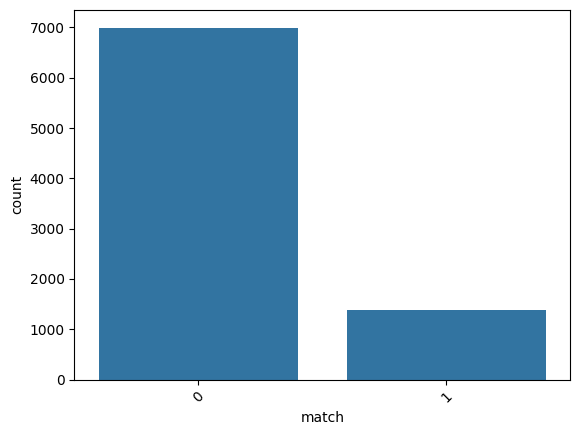

In [34]:
sns.countplot(x = df["match"], data = df)
plt.xticks(rotation = 45)
plt.show()

- Nie zbilansowana zmienna celu, trzeba będzie ją później zbilansować.

### Badanie korelacji

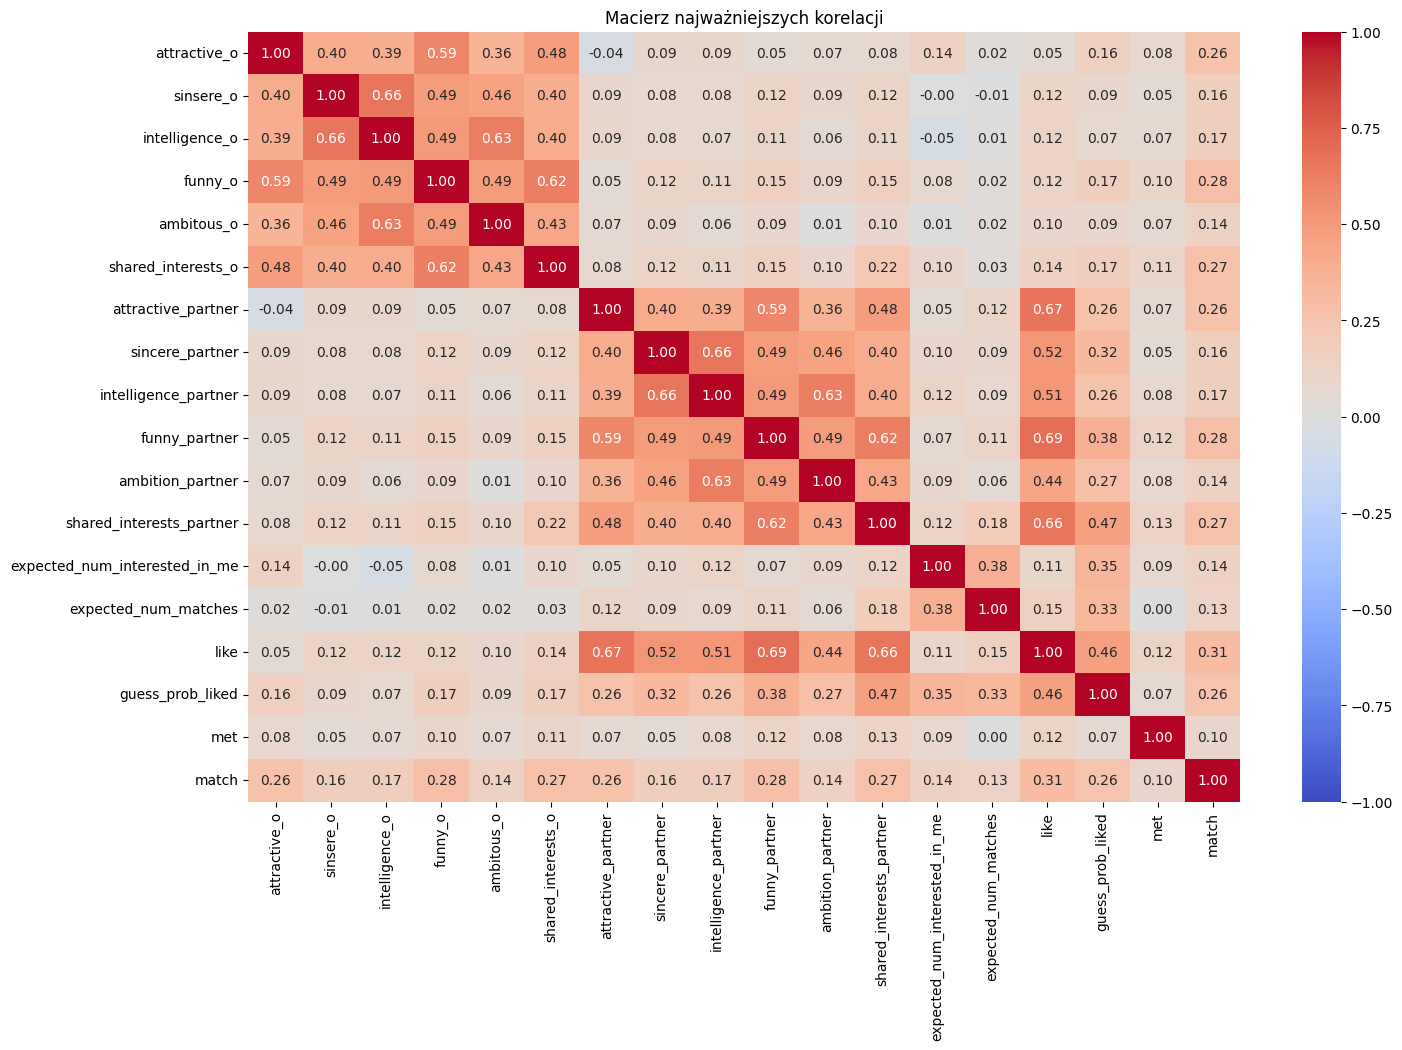

In [41]:
plt.figure(figsize = (16, 10))
encoded = pd.concat([df.drop(columns="match"),df["match"]], axis = 1)
corr = encoded.corr(numeric_only = True)
target_corr = corr["match"]
significant_corr = target_corr[target_corr.abs() > 0.1].index.to_list()
sns.heatmap(corr.loc[significant_corr, significant_corr], vmin= -1 , vmax= 1, cmap = "coolwarm", annot =True, fmt = ".2f")
plt.title("Macierz najważniejszych korelacji")
plt.show()

### Usuwanie kolumn, które dają wyciek danych.

In [23]:
leakage_cols = [
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
    'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner',
    'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner',
    'like', 'd_like', 'guess_prob_liked', 'd_guess_prob_liked'
]

df = df.drop(columns=leakage_cols)
print(f"Rozmiar po usunięciu wycieków: {df.shape}")

Rozmiar po usunięciu wycieków: (8378, 93)


### Profilowanie

In [40]:
profile_cols = ['gender', 'age', 'race', 'field', 'sports', 'tvsports', 'exercise', 
                'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 
                'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga']

df_filled = df[profile_cols].fillna("Missing")
user_ids = df_filled.groupby(profile_cols).ngroup()
user_counts = user_ids.value_counts()
relevant_users = user_counts[user_counts >= 5].index
train_users, test_users = train_test_split(relevant_users, test_size = 0.2, random_state = 67)




### Podział danych względem usera. 

In [35]:
test_indices = []
for user in test_users:
    u_idx = user_ids[user_ids == user].index
    test_indices.extend(u_idx[:5])
train_indices = user_ids[user_ids.isin(train_users)].index
X_train = df.loc[train_indices].drop(columns=['match'])
y_train = df.loc[train_indices]['match']
X_test = df.loc[test_indices].drop(columns=['match'])
y_test = df.loc[test_indices]['match']
user_ids_train = user_ids.loc[train_indices]
user_ids_test = user_ids.loc[test_indices]
print(f"Dane treningowe (X_train): {X_train.shape}")
print(f"Dane testowe (X_test): {X_test.shape}")


Dane treningowe (X_train): (6712, 92)
Dane testowe (X_test): (550, 92)
